# nb06 — реальная модель капитала: честная рампа + июнь/июль

**Что изменилось против nb05.** nb05 моделировал рампу только как «сколько денег вложено»
(`frac = min(1, base·k(k+1)/2)`), оставляя цену входа эталонной. Это было неполно. Живой бот
**перестаёт доливать, как только набрал размер**, поэтому средняя цена считается только по
первым N заливкам, а не по всем `k`. Число используемых заливок зависит от base: при 0.05 их 6,
при 0.40 — всего 2. Отсюда размен, которого в nb05 не было: больше base → больше капитала,
но хуже цена входа. Вывод nb05 «front-load 0.40 бесплатен» **отменяется**.

Книга пересобрана (`_build_signals_v3.py`) с обоими эффектами сразу. Валидация: режим `et`
(конвенция эталона) воспроизводит старый `pnl6` с расхождением **0.000e+00**, так что всё
расхождение ниже — следствие рампы, а не побочных отличий.

Формула рампы проверена независимо против **1836 логированных сделок бота**: совпадение 99.35%,
остаток — дрейф equity (~$975, не $1000). Исключения: 12 сделок с кэпом ёмкости (0.65%) и
4 с пересчётом цели после рестарта (0.22%).

**Плюс две новые вещи:**
1. Окно расширено до **2026-07-31** — июль модель никогда не видела (исследование кончалось
   30.06, бот торговал июль). Это первый настоящий OOS за всю линию.
2. Вселенная на диске выросла с 218 до 543 символов, дающих события. Рост — в основном
   **токенизированные акции**, ночь и выходные у которых добиты плоскими барами с нулевым
   объёмом. Для памп-гейта это яд (медиана объёма уползает к нулю → гейт проходится на открытии
   сессии). Ставим причинный пер-эвентный барьер по активности.

In [1]:
import sys, os, re
if os.path.basename(os.getcwd()) != "pump_dump_v2":
    os.chdir(r"C:\projects\researchlab\notebooks\pump_dump_v2")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from _engine import (load_signals_v3, build_book_v3, ffrac_v3, ramp_frac,
                     run_dca, metrics, naive, BASES_V3)
from _lab import show
pd.set_option("display.width", 250)

PUMP, DUMP = load_signals_v3()
NZV = pd.read_parquet("_out/nzv1440.parquet"); NZV["entry"] = naive(NZV["entry"])
print(f"сырые события v3:  pump {len(PUMP)}  dump {len(DUMP)}")
print(f"окно:              {min(PUMP.entry.min(), DUMP.entry.min())} .. {max(PUMP.entry.max(), DUMP.entry.max())}")
print(f"символов:          {len(set(PUMP.sym) | set(DUMP.sym))}")

# вселенная боевого бота — парсим из его конфига, чтобы не разъехалось
cfg = open(r"C:\projects\pump_fade_bot\config.py", encoding="utf-8").read()
BOT_UNIVERSE = set(re.findall(r'"([A-Z0-9]+USDT)"', re.search(r'"symbols":\s*\[(.*?)\n    \]', cfg, re.S).group(1)))
print(f"вселенная бота:    {len(BOT_UNIVERSE)} символов")

сырые события v3:  pump 49833  dump 20706
окно:              2024-01-02 00:01:00 .. 2026-07-31 10:45:00
символов:          578
вселенная бота:    120 символов


## 1. Барьеры на данные

Три штуки, каждый со своей причиной. Считаем, сколько событий снимает каждый.

- **Обрезка июля на 2026-07-31 11:00.** Загрузчик шёл по алфавиту A→Z 4.75 часа (корреляция
  позиции в алфавите с последним баром 0.9993), так что в последние часы вселенная схлопывается
  по алфавиту. Кросс-секционной логики здесь нет, но режем на всякий случай — стоит копейки.
- **Гейт активности `nzv1440`** — доля минут с ненулевым объёмом в трейлинг-1440. Причинный,
  окно кончается ДО бара-триггера. Задумывался против фейковых пампов на добитых барах —
  **оказался почти no-op, см. ниже.** Оставлен как проверка свойства, а не как фильтр.
- **Мёртвые директории НЕ выбрасываем** — 18 символов с данными, оборвавшимися в 2024–2026-04,
  это делистнутые монеты. Выбросить их значило бы завести survivorship bias.

In [2]:
JULY_CUT = pd.Timestamp("2026-07-31 11:00")
NZV_MIN  = 0.50            # чувствительность проверяется ниже

def guard(df, nzv_min=NZV_MIN, cut=JULY_CUT, universe=None):
    d = df.merge(NZV, on=["sym", "entry"], how="left")
    steps = [("сырые", len(d))]
    d = d[d.entry < cut];                       steps.append(("после обрезки июля", len(d)))
    d = d[d.nzv1440.fillna(0) >= nzv_min];      steps.append((f"после nzv>={nzv_min:.0%}", len(d)))
    if universe is not None:
        d = d[d.sym.isin(universe)];            steps.append(("после вселенной бота", len(d)))
    return d.reset_index(drop=True), steps

for name, raw in [("pump", PUMP), ("dump", DUMP)]:
    _, st = guard(raw)
    line = f"  {name:5s} " + " -> ".join(f"{lab} {n}" for lab, n in st)
    print(line)

print("\nчувствительность к порогу активности (событий остаётся):")
rows = []
for thr in [0.0, 0.3, 0.5, 0.7, 0.9]:
    p, _ = guard(PUMP, nzv_min=thr); d, _ = guard(DUMP, nzv_min=thr)
    rows.append(dict(nzv_min=f"{thr:.0%}", pump=len(p), dump=len(d),
                     pump_syms=p.sym.nunique(), dump_syms=d.sym.nunique(),
                     pump_mean=f"{p.pnl_b0.mean()*100:+.2f}%", dump_mean=f"{d.pnl_b0.mean()*100:+.2f}%"))
print(pd.DataFrame(rows).to_string(index=False))

  pump  сырые 49833 -> после обрезки июля 49833 -> после nzv>=50% 49833
  dump  сырые 20706 -> после обрезки июля 20706 -> после nzv>=50% 20706

чувствительность к порогу активности (событий остаётся):
nzv_min  pump  dump  pump_syms  dump_syms pump_mean dump_mean
     0% 49833 20706        573        549    -0.30%    +2.10%
    30% 49833 20706        573        549    -0.30%    +2.10%
    50% 49833 20706        573        549    -0.30%    +2.10%
    70% 47765 20031        564        538    -0.31%    +2.10%
    90% 41959 18087        535        526    -0.37%    +2.13%


In [3]:
print("ПОЧЕМУ гейт оказался no-op — детектор уже делает это сам:\n")
print(f"  min(nzv1440) по всем {len(NZV)} событиям = {NZV.nzv1440.min():.4f}   событий с nzv<0.5: {(NZV.nzv1440<0.5).sum()}")
print("  Причина: и памп-, и дамп-ветка требуют median(объём за 1440м) > 0 (иначе surge=NaN и")
print("  строка выпадает на .dropna()). А медиана > 0 математически ЭКВИВАЛЕНТНА '>50% ненулевых")
print("  баров'. То есть порог 50% встроен в детектор с самого начала.\n")

EQ = ["WMTUSDT","BRKBUSDT","ASMLUSDT","KLACUSDT","EWJUSDT","TQQQUSDT","SQQQUSDT","CSCOUSDT","IBMUSDT",
      "ADBEUSDT","UNHUSDT","LLYUSDT","AMGNUSDT","GILDUSDT","REGNUSDT","COSTUSDT","XLEUSDT","CRWDUSDT",
      "USDEUSDT","RLUSDUSDT","UVXYUSDT","SMCIUSDT","LRCXUSDT","AMATUSDT","GLWUSDT","HPEUSDT","CIENUSDT",
      "NOWUSDT","DELLUSDT","PYPLUSDT","MAUSDT","KOUSDT","PEPUSDT"]
allev = pd.concat([PUMP[["sym","entry"]], DUMP[["sym","entry"]]])
inbook = sorted(set(allev.sym) & set(EQ))
n_eq = allev.sym.isin(EQ).sum()
print(f"  токенизированных акций в книге: {len(inbook)}/{len(EQ)} -> {inbook}")
print(f"  событий от них: {n_eq} из {len(allev)} = {n_eq/len(allev)*100:.2f}%")
print("\n  ВЫВОД: загрязнение акциями было ложной тревогой. Аудит данных был прав по механизму")
print("  (24% баров с нулевым объёмом, 127 новых листингов-акций), но детектор их уже не пускает.")

ПОЧЕМУ гейт оказался no-op — детектор уже делает это сам:

  min(nzv1440) по всем 70539 событиям = 0.5000   событий с nzv<0.5: 0
  Причина: и памп-, и дамп-ветка требуют median(объём за 1440м) > 0 (иначе surge=NaN и
  строка выпадает на .dropna()). А медиана > 0 математически ЭКВИВАЛЕНТНА '>50% ненулевых
  баров'. То есть порог 50% встроен в детектор с самого начала.

  токенизированных акций в книге: 7/33 -> ['AMATUSDT', 'DELLUSDT', 'GLWUSDT', 'IBMUSDT', 'KLACUSDT', 'SMCIUSDT', 'UVXYUSDT']
  событий от них: 18 из 70539 = 0.03%

  ВЫВОД: загрязнение акциями было ложной тревогой. Аудит данных был прав по механизму
  (24% баров с нулевым объёмом, 127 новых листингов-акций), но детектор их уже не пускает.


Так что порог 50% ничего не режет — он документирует свойство, которое и так выполняется.
Поднимать его выше (например до 90%, что сняло бы ~15% книги) — это уже **изменение стратегии**,
а не чистка данных: под нож пойдут тонкие, но непрерывно торгуемые микрокапы, то есть ровно та
часть вселенной, где живёт edge. Не делаем молча.

## 2. Две вселенные

Модель на 543 символах увидит диверсификацию, которой **у бота нет** — он торгует 120.
Считаем обе; главной цифрой держим вселенную бота, потому что это то, что исполнимо.
Расширение вселенной становится отдельным кандидатом на улучшение с измеримой ценой.

In [4]:
def make_book(base, universe=None, nzv_min=NZV_MIN, filtered=True):
    p, _ = guard(PUMP, nzv_min=nzv_min, universe=universe)
    d, _ = guard(DUMP, nzv_min=nzv_min, universe=universe)
    return build_book_v3(p, d, base=base, filtered=filtered)

BOOKS = {}
for uname, uni in [("бот (120)", BOT_UNIVERSE), ("вся (543)", None)]:
    for bname, base in [("эталон", None), ("честная 0.05", 0.05)]:
        BOOKS[(uname, bname)] = make_book(base, uni)

print(f"{'вселенная':12s} {'сайзинг':14s} {'сделок':>7s} {'pump':>7s} {'dump':>7s} "
      f"{'p:d':>6s} {'символов':>9s} {'frac ср':>8s}")
for (u, b), B in BOOKS.items():
    np_, nd = (B.stream == "pump").sum(), (B.stream == "dump").sum()
    print(f"{u:12s} {b:14s} {len(B):7d} {np_:7d} {nd:7d} {np_/max(nd,1):6.2f} "
          f"{B.sym.nunique():9d} {B.frac.mean()*100:7.1f}%")

вселенная    сайзинг         сделок    pump    dump    p:d  символов  frac ср
бот (120)    эталон           12705    8333    4372   1.91       116   100.0%
бот (120)    честная 0.05     11581    7286    4295   1.70       116    40.4%
вся (543)    эталон           58906   40535   18371   2.21       572   100.0%
вся (543)    честная 0.05     55072   36085   18987   1.90       567    42.2%


## 3. Честная лесенка

`эталон` = старая (неисполнимая) модель: полный размер на каждую сделку.
`честная 0.05` = то, что бот делает на самом деле.

In [5]:
MODES = {"safe": (0.03, 0.03), "med": (0.04, 0.03), "agg": (0.05, 0.03), "sagg": (0.08, 0.03)}

def ladder(book, honest):
    out = {}
    for mode, (fp, fd) in MODES.items():
        R = run_dca(book, ffrac=ffrac_v3(book, fp, fd, honest=honest))
        out[mode] = metrics(R, "")
    return out

RES = {}
for (u, b), B in BOOKS.items():
    RES[(u, b)] = ladder(B, honest=(b != "эталон"))

for col in ["mult", "Sharpe", "maxDD"]:
    print(f"=== {col} ===")
    t = pd.DataFrame({f"{u} | {b}": {m: RES[(u, b)][m][col] for m in MODES} for (u, b) in RES}).T
    print(t.to_string(), "\n")

=== mult ===
                            safe     med     agg   sagg
бот (120) | эталон          4.8x    4.7x    4.5x   3.8x
бот (120) | честная 0.05    0.6x    0.5x    0.4x   0.3x
вся (543) | эталон        103.6x  114.8x  117.3x  98.1x
вся (543) | честная 0.05    0.3x    0.2x    0.1x   0.1x 

=== Sharpe ===
                           safe    med    agg   sagg
бот (120) | эталон         2.80   2.53   2.27   1.75
бот (120) | честная 0.05  -1.67  -1.83  -1.92  -2.02
вся (543) | эталон         5.09   4.57   4.09   3.16
вся (543) | честная 0.05  -1.82  -1.82  -1.82  -1.69 

=== maxDD ===
                            safe     med     agg    sagg
бот (120) | эталон        -11.1%  -14.2%  -18.9%  -37.4%
бот (120) | честная 0.05  -60.7%  -71.7%  -79.7%  -92.0%
вся (543) | эталон        -21.0%  -27.3%  -32.5%  -66.6%
вся (543) | честная 0.05  -83.2%  -90.5%  -94.9%  -99.1% 



## 4. Июль — настоящий OOS

Исследование всегда кончалось 30 июня. Бот стартовал 8 июля. Эти данные модель не видела.

In [6]:
JUL0, JUL1 = pd.Timestamp("2026-07-01"), JULY_CUT
for uname, uni in [("бот (120)", BOT_UNIVERSE), ("вся (543)", None)]:
    B = BOOKS[(uname, "честная 0.05")]
    for lab, sub in [("вся история", B),
                     ("июнь-2026", B[(B.entry >= "2026-06-01") & (B.entry < JUL0)]),
                     ("ИЮЛЬ-2026 (OOS)", B[(B.entry >= JUL0) & (B.entry < JUL1)])]:
        if len(sub) == 0:
            continue
        p, d = sub[sub.stream == "pump"], sub[sub.stream == "dump"]
        print(f"  {uname:11s} {lab:17s} n={len(sub):6d}  p:d {len(p)/max(len(d),1):5.2f}  "
              f"pump {p.pnl.mean()*100:+6.2f}%  dump {d.pnl.mean()*100:+6.2f}%  "
              f"все {sub.pnl.mean()*100:+6.2f}%  медиана {sub.pnl.median()*100:+6.2f}%")
    print()

  бот (120)   вся история       n= 11581  p:d  1.70  pump  -0.53%  dump  +3.00%  все  +0.77%  медиана  +1.19%
  бот (120)   июнь-2026         n=   978  p:d  0.66  pump  -1.20%  dump  +2.40%  все  +0.97%  медиана  +0.70%
  бот (120)   ИЮЛЬ-2026 (OOS)   n=   490  p:d  0.65  pump  +1.90%  dump  -0.17%  все  +0.64%  медиана  +0.86%

  вся (543)   вся история       n= 55072  p:d  1.90  pump  -0.09%  dump  +2.09%  все  +0.66%  медиана  +1.23%
  вся (543)   июнь-2026         n=  3067  p:d  1.12  pump  +0.07%  dump  +0.87%  все  +0.45%  медиана  +1.11%
  вся (543)   ИЮЛЬ-2026 (OOS)   n=  2255  p:d  1.07  pump  +0.51%  dump  +0.15%  все  +0.34%  медиана  +0.91%



In [7]:
# помесячно: не сломался ли режим в последние месяцы
B = BOOKS[("бот (120)", "честная 0.05")]
B["m"] = B.entry.dt.to_period("M")
mm = B.groupby("m").agg(n=("pnl", "size"), mean=("pnl", lambda s: s.mean()*100),
                        med=("pnl", lambda s: s.median()*100),
                        pump=("stream", lambda s: (s == "pump").sum()),
                        dump=("stream", lambda s: (s == "dump").sum()),
                        syms=("sym", "nunique"))
mm["p:d"] = (mm["pump"] / mm["dump"].clip(lower=1)).round(2)
print("вселенная бота, честная рампа — помесячно (последние 14):")
print(mm.tail(14).round(2).to_string())
print(f"\nмедиана p:d по всей истории {mm['p:d'].median():.2f} | июнь {mm['p:d'].get(pd.Period('2026-06'),float('nan')):.2f}"
      f" | июль {mm['p:d'].get(pd.Period('2026-07'),float('nan')):.2f}   (у бота по факту 0.63)")

вселенная бота, честная рампа — помесячно (последние 14):
           n  mean   med  pump  dump  syms   p:d
m                                               
2025-06   99  0.87  1.45    62    37    27  1.68
2025-07  229  0.80  0.64   145    84    40  1.73
2025-08  181  0.46  1.06   101    80    42  1.26
2025-09  312  0.00  0.95   148   164    54  0.90
2025-10  502  2.38  2.04   234   268    98  0.87
2025-11  407  0.89  1.60   216   191    76  1.13
2025-12  281  1.51  1.42   146   135    43  1.08
2026-01  286  1.83  3.24   137   149    86  0.92
2026-02  263  3.00  3.46   125   138    88  0.91
2026-03  120  1.12  1.92    91    29    49  3.14
2026-04  500  1.27  1.57   214   286    48  0.75
2026-05  367  0.81  1.62   163   204    41  0.80
2026-06  978  0.97  0.70   390   588    70  0.66
2026-07  490  0.64  0.86   193   297    42  0.65

медиана p:d по всей истории 1.71 | июнь 0.66 | июль 0.65   (у бота по факту 0.63)


## 5. Свип базы рампы — предварительный (полноценно в C1)

Все базы уже лежат в parquet, поэтому смотрим сразу. Здесь виден размен, которого не было
в nb05: капитал растёт с base, цена входа портится.

In [8]:
rows = []
for base in BASES_V3:
    B = make_book(base, BOT_UNIVERSE)
    R = run_dca(B, ffrac=ffrac_v3(B, 0.05, 0.03, honest=True))
    m = metrics(R, "")
    rows.append(dict(base=base, n=len(B), frac_mean=f"{B.frac.mean()*100:.0f}%",
                     kused_med=int(B.kused.median()),
                     pnl_mean=f"{B.pnl.mean()*100:+.2f}%", pnl_med=f"{B.pnl.median()*100:+.2f}%",
                     mult=m["mult"], Sharpe=m["Sharpe"], maxDD=m["maxDD"]))
B = make_book(None, BOT_UNIVERSE)
R = run_dca(B, ffrac=ffrac_v3(B, 0.05, 0.03, honest=False)); m = metrics(R, "")
rows.append(dict(base="эталон", n=len(B), frac_mean="100%", kused_med=int(B.kused.median()),
                 pnl_mean=f"{B.pnl.mean()*100:+.2f}%", pnl_med=f"{B.pnl.median()*100:+.2f}%",
                 mult=m["mult"], Sharpe=m["Sharpe"], maxDD=m["maxDD"]))
print("вселенная бота, agg (pump 5% / dump 3%):")
print(pd.DataFrame(rows).to_string(index=False))

вселенная бота, agg (pump 5% / dump 3%):
  base     n frac_mean  kused_med pnl_mean pnl_med mult Sharpe  maxDD
  0.05 11581       40%          2   +0.77%  +1.19% 0.4x  -1.92 -79.7%
   0.1 11254       51%          2   +0.50%  +1.07% 0.4x  -1.94 -82.3%
   0.2 10870       63%          2   +0.25%  +0.96% 0.4x  -1.94 -83.5%
   0.4 10522       77%          2   -0.00%  +0.88% 0.3x  -2.07 -86.1%
   0.6 10413       85%          2   -0.08%  +0.82% 0.4x  -1.95 -85.4%
   1.0 10144      100%          1   -0.27%  +0.58% 0.4x  -2.01 -86.6%
эталон 12705      100%          2   +1.23%  +1.43% 4.5x   2.27 -18.9%


[saved] notebooks\pump_dump_v2\_out\v2_nb06_honest_capital.png


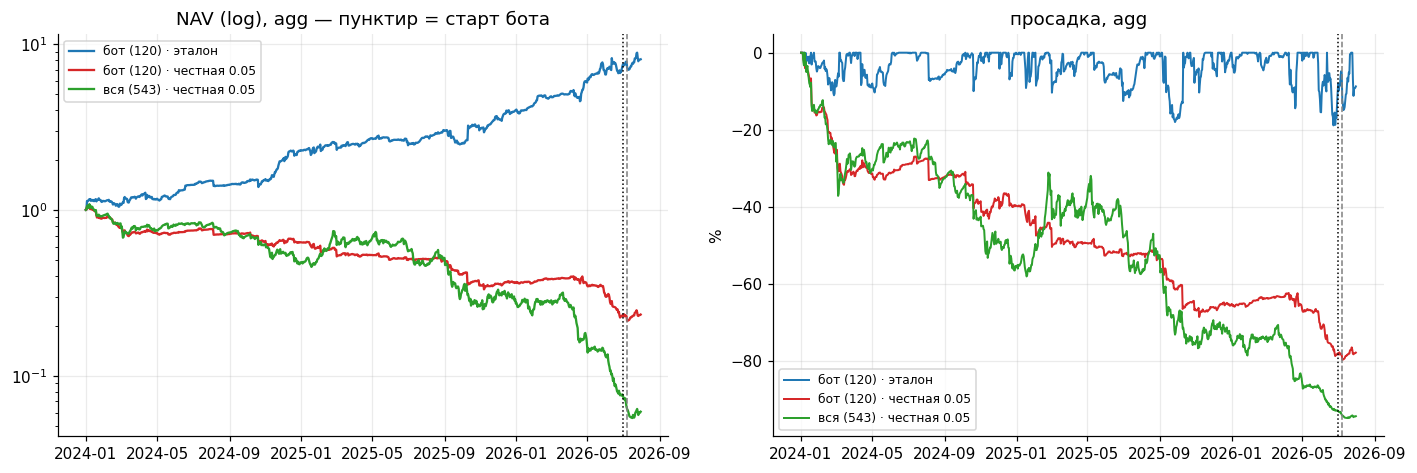

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for (u, b), col in [(("бот (120)", "эталон"), "#1f77b4"), (("бот (120)", "честная 0.05"), "#d62728"),
                    (("вся (543)", "честная 0.05"), "#2ca02c")]:
    B = BOOKS[(u, b)]
    nav = run_dca(B, ffrac=ffrac_v3(B, 0.05, 0.03, honest=(b != "эталон")))["nav"]
    ax[0].plot(nav.index, nav.values, color=col, lw=1.5, label=f"{u} · {b}")
    ax[1].plot(nav.index, (nav / nav.cummax() - 1).values * 100, color=col, lw=1.3, label=f"{u} · {b}")
for a in ax:
    a.axvline(pd.Timestamp("2026-07-01"), color="k", ls=":", lw=1)
    a.axvline(pd.Timestamp("2026-07-08"), color="grey", ls="--", lw=1)
ax[0].set_yscale("log"); ax[0].set_title("NAV (log), agg — пунктир = старт бота"); ax[0].legend(fontsize=8)
ax[1].set_title("просадка, agg"); ax[1].set_ylabel("%"); ax[1].legend(fontsize=8)
show("v2_nb06_honest_capital");

## Выводы

*(заполняется после прогона — см. вывод ячеек выше)*